# **Project**: Social Media Productivity

## Business Problem: How does social media usage impact employee productivity, stress levels, and job satisfaction?

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\ysaih\Downloads\social_media_vs_productivity.csv")
df

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
2,32,Male,Finance,NaN,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,NaN,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
4,25,Male,IT,NaN,Telegram,66,6.214096,8.868753,NaN,7.0,5.405706,1.876254,1,False,True,1,30,10.653519,9.693060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,34,Female,Health,1.877297,Facebook,59,10.226358,3.348512,3.465815,8.0,5.480462,1.412655,9,False,False,4,5,21.776927,NaN
29996,39,Male,Health,4.437784,Instagram,46,4.692862,8.133213,6.659294,8.0,3.045393,0.148936,3,False,False,1,29,4.111370,6.155613
29997,42,Male,Education,17.724981,TikTok,64,10.915036,8.611005,8.658912,5.0,5.491520,1.224296,10,False,False,1,2,1.888315,6.285237
29998,20,Female,Education,3.796634,Instagram,56,6.937410,7.767076,6.895583,8.0,6.816069,0.234483,1,False,False,2,9,12.511871,7.854711


In [5]:
df.info() # It is used to get a quick summary of the dataset structure.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             30000 non-null  int64  
 1   gender                          30000 non-null  object 
 2   job_type                        30000 non-null  object 
 3   daily_social_media_time         27235 non-null  float64
 4   social_platform_preference      30000 non-null  object 
 5   number_of_notifications         30000 non-null  int64  
 6   work_hours_per_day              30000 non-null  float64
 7   perceived_productivity_score    28386 non-null  float64
 8   actual_productivity_score       27635 non-null  float64
 9   stress_level                    28096 non-null  float64
 10  sleep_hours                     27402 non-null  float64
 11  screen_time_before_sleep        27789 non-null  float64
 12  breaks_during_work              

In [18]:
df.head() # It shows the first 5 rows of the dataset

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
2,32,Male,Finance,NaN,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,NaN,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
4,25,Male,IT,NaN,Telegram,66,6.214096,8.868753,NaN,7.0,5.405706,1.876254,1,False,True,1,30,10.653519,9.693060


In [19]:
df.tail() # It shows the last 5 rows of the dataset

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
29995,34,Female,Health,1.877297,Facebook,59,10.226358,3.348512,3.465815,8.0,5.480462,1.412655,9,False,False,4,5,21.776927,NaN
29996,39,Male,Health,4.437784,Instagram,46,4.692862,8.133213,6.659294,8.0,3.045393,0.148936,3,False,False,1,29,4.111370,6.155613
29997,42,Male,Education,17.724981,TikTok,64,10.915036,8.611005,8.658912,5.0,5.491520,1.224296,10,False,False,1,2,1.888315,6.285237
29998,20,Female,Education,3.796634,Instagram,56,6.937410,7.767076,6.895583,8.0,6.816069,0.234483,1,False,False,2,9,12.511871,7.854711
29999,44,Male,Unemployed,NaN,Twitter,70,8.069883,6.311227,5.402726,3.0,6.765248,0.993090,5,False,True,1,4,6.324954,7.388790


In [6]:
df.isnull().sum() #It is used to check missing values in each column of the dataset.

age                                  0
gender                               0
job_type                             0
daily_social_media_time           2765
social_platform_preference           0
number_of_notifications              0
work_hours_per_day                   0
perceived_productivity_score      1614
actual_productivity_score         2365
stress_level                      1904
sleep_hours                       2598
screen_time_before_sleep          2211
breaks_during_work                   0
uses_focus_apps                      0
has_digital_wellbeing_enabled        0
coffee_consumption_per_day           0
days_feeling_burnout_per_month       0
weekly_offline_hours                 0
job_satisfaction_score            2730
dtype: int64

In [20]:
df.columns = df.columns.str.strip().str.lower() #Cleaned column names by removing spaces and converting to lowercase.

In [24]:
df.drop(columns=['daily_social_media_time','perceived_productivity_score','actual_productivity_score','stress_level','sleep_hours',
    'screen_time_before_sleep',
    'job_satisfaction_score'
], inplace=True, errors='ignore') #Removed unnecessary rows or columns from the dataset.

In [25]:
df

,age,gender,job_type,social_platform_preference,number_of_notifications,work_hours_per_day,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours
0,56,Male,Unemployed,Facebook,61,6.753558,8,False,False,4,11,21.927072
1,46,Male,Health,Twitter,59,9.169296,7,True,True,2,25,0.000000
2,32,Male,Finance,Twitter,57,7.910952,0,True,False,3,17,10.322044
3,60,Female,Unemployed,Facebook,59,6.355027,1,False,False,0,4,23.876616
4,25,Male,IT,Telegram,66,6.214096,1,False,True,1,30,10.653519
...,...,...,...,...,...,...,...,...,...,...,...,...
29995,34,Female,Health,Facebook,59,10.226358,9,False,False,4,5,21.776927
29996,39,Male,Health,Instagram,46,4.692862,3,False,False,1,29,4.111370
29997,42,Male,Education,TikTok,64,10.915036,10,False,False,1,2,1.888315
29998,20,Female,Education,Instagram,56,6.937410,1,False,False,2,9,12.511871


In [44]:
df['age'].skew() #Calculated the skewness of the age column to check data distribution.

np.float64(0.015305114402243351)

In [46]:
df['age'].mean() #Calculated the average age value in the dataset.

np.float64(41.486866666666664)

In [35]:
df['stress_level'].median() #calculated the median stress level in the dataset

5.514058940774487

In [36]:
df['sleep_hours'].mean() # calculated the average sleep hours in the dataset

np.float64(6.500082266758014)

In [45]:
df['work_hours_per_day'].skew() # calculated the skewness of work hours per day column to check data distrib

np.float64(-0.03816180487764749)

In [52]:
df['gender'].mode() #Identified the most frequent gender in the dataset

0    Male
Name: gender, dtype: object

In [54]:
df['work_hours_per_day'].median() #calculated the median work hours per day in the dataset

6.990641293098886

In [56]:
df['daily_social_media_time'].median() #calculated the median daily social media time in the dataset

3.0266994974460855

In [85]:
df['gender'].value_counts() # counted the frequency of how many males and females are there in the dataset

gender
Male      14452
Female    14370
Other      1178
Name: count, dtype: int64

In [59]:
df['gender'].value_counts(normalize=True) # Calculated the percentage distribution of gender values

gender
Male      0.481733
Female    0.479000
Other     0.039267
Name: proportion, dtype: float64

In [89]:
sum(df['gender']== 'Male') # calculating the total sum of males in the gender column in the dataset

14452

In [61]:
df['job_type'].unique() # Displayed all unique job types in the dataset

array(['Unemployed', 'Health', 'Finance', 'IT', 'Education', 'Student'],
      dtype=object)

In [62]:
df['job_type'].nunique()  # counted the number of unique job types in the dataset

6

In [6]:
df

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
2,32,Male,Finance,NaN,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,NaN,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
4,25,Male,IT,NaN,Telegram,66,6.214096,8.868753,NaN,7.0,5.405706,1.876254,1,False,True,1,30,10.653519,9.693060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,34,Female,Health,1.877297,Facebook,59,10.226358,3.348512,3.465815,8.0,5.480462,1.412655,9,False,False,4,5,21.776927,NaN
29996,39,Male,Health,4.437784,Instagram,46,4.692862,8.133213,6.659294,8.0,3.045393,0.148936,3,False,False,1,29,4.111370,6.155613
29997,42,Male,Education,17.724981,TikTok,64,10.915036,8.611005,8.658912,5.0,5.491520,1.224296,10,False,False,1,2,1.888315,6.285237
29998,20,Female,Education,3.796634,Instagram,56,6.937410,7.767076,6.895583,8.0,6.816069,0.234483,1,False,False,2,9,12.511871,7.854711


In [64]:
df['perceived_productivity_score']

0        8.040464
1        5.063368
2        3.861762
3        2.916331
4        8.868753
           ...   
29995    3.348512
29996    8.133213
29997    8.611005
29998    7.767076
29999    6.311227
Name: perceived_productivity_score, Length: 30000, dtype: float64

In [65]:
df['perceived_productivity_score'].mean() # Calculated the average perceived productivity score

np.float64(5.509858845460942)

In [66]:
df['perceived_productivity_score'].median() # Calculated the median perceived productivity score

5.525186101084879

In [67]:
df['perceived_productivity_score'].mode() # Identified the most frequent value in the perceived productivity score column

0    2.741304
1    3.092851
2    4.297745
3    5.758945
4    7.376005
Name: perceived_productivity_score, dtype: float64

In [68]:
df['perceived_productivity_score'].describe() # Generated statistical summary of the dataset

count    30000.000000
mean         5.509859
std          2.024080
min          2.000252
25%          3.752716
50%          5.525186
75%          7.263416
max          8.999376
Name: perceived_productivity_score, dtype: float64

In [69]:
df['perceived_productivity_score'].min() # Calculated the minimum productivity score in the dataset

2.0002524300446303

In [70]:
df['perceived_productivity_score'].max() # Calculated the maximum productivity score in the dataset

8.999375647878052

In [72]:
df['perceived_productivity_score'].std() # Calculated the sample standard deviation of productivity scores

2.02408047976851

In [73]:
df['perceived_productivity_score'].std(ddof=0) # Calculated the population standard deviation of productivity scores

2.02404674481272

In [74]:
df['perceived_productivity_score'].var()  # Calculated the sample variance of productivity scores

4.096901788579921

In [75]:
df['perceived_productivity_score'].var(ddof=0)  # Calculated the population variance of productivity scores

4.096765225186968

In [76]:
df['perceived_productivity_score'].quantile()  # Calculated the median for the productivity score

np.float64(5.525186101084879)

In [77]:
df['perceived_productivity_score'].quantile(0.25) # Calculated the first quartile for the productivity score

np.float64(3.752716303123146)

In [78]:
df['perceived_productivity_score'].quantile(0.50)   # Calculated the second quartile for the productivity score

np.float64(5.525186101084879)

In [79]:
df['perceived_productivity_score'].quantile(0.75)   # Calculated the third quartile for the productivity score

np.float64(7.263415771029892)

In [80]:
Q3 = df['perceived_productivity_score'].quantile(0.75)   # Calculated the third quartile for the productivity score
Q1 = df['perceived_productivity_score'].quantile(0.25)   # Calculated the first quartile for the productivity score

In [81]:
Q3-Q1  # Calculated the IQR by subtracting Q1 from Q3

np.float64(3.5106994679067456)

In [82]:
df.corr(numeric_only= True)   # Calculated the correlation between all numerical columns in the dataset

,age,daily_social_media_time,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
age,1.000000,-0.006091,-0.003799,-0.003231,0.009990,0.010384,0.004706,0.001802,0.004088,-0.010918,0.001524,-0.005594,-0.001162,-0.002998,0.003086,0.011835
daily_social_media_time,-0.006091,1.000000,0.003503,-0.003284,-0.008252,-0.009589,0.001779,0.015774,-0.003488,0.013062,-0.003696,-0.005331,-0.005191,0.000477,-0.004927,-0.000882
number_of_notifications,-0.003799,0.003503,1.000000,0.013068,-0.002932,0.001125,-0.004165,0.002731,0.015589,0.008816,0.004320,-0.001722,0.006088,0.005248,-0.000938,-0.003864
work_hours_per_day,-0.003231,-0.003284,0.013068,1.000000,0.002991,-0.001939,0.002973,0.002334,-0.008116,-0.008151,-0.000395,0.002251,-0.003071,0.003391,-0.002061,-0.005154
perceived_productivity_score,0.009990,-0.008252,-0.002932,0.002991,1.000000,0.847379,0.004171,-0.012326,0.001607,-0.003633,-0.003465,-0.005883,0.003141,-0.010177,-0.006931,0.736453
actual_productivity_score,0.010384,-0.009589,0.001125,-0.001939,0.847379,1.000000,0.003461,-0.008808,0.002462,-0.003058,0.000764,-0.008314,0.003667,-0.011517,-0.006568,0.746023
stress_level,0.004706,0.001779,-0.004165,0.002973,0.004171,0.003461,1.000000,0.002863,-0.003075,0.001530,0.003812,-0.012134,-0.001297,-0.000401,-0.002461,0.001558
sleep_hours,0.001802,0.015774,0.002731,0.002334,-0.012326,-0.008808,0.002863,1.000000,-0.005615,0.005309,0.000848,0.002099,0.010348,-0.006923,-0.007230,-0.004339
screen_time_before_sleep,0.004088,-0.003488,0.015589,-0.008116,0.001607,0.002462,-0.003075,-0.005615,1.000000,-0.006277,-0.008810,0.002275,-0.005164,0.000215,-0.003708,0.002154
breaks_during_work,-0.010918,0.013062,0.008816,-0.008151,-0.003633,-0.003058,0.001530,0.005309,-0.006277,1.000000,-0.004046,0.001016,0.004647,-0.003668,0.006579,-0.004207


In [83]:
df.corr(numeric_only= True, method='spearman')  # Calculated the Spearman correlation between numerical columns in the dataset
                                                # Spearman correlation measures the monotonic relationship between variables

,age,daily_social_media_time,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
age,1.000000,-0.007865,-0.004915,-0.003191,0.010019,0.010453,0.004684,-0.000540,0.003862,-0.010928,0.001538,-0.005608,0.000533,-0.002985,0.004034,0.012486
daily_social_media_time,-0.007865,1.000000,0.005951,-0.002348,-0.006076,-0.005795,0.004721,0.013846,-0.003387,0.008177,-0.001882,-0.001287,-0.005273,0.001651,-0.005392,0.001353
number_of_notifications,-0.004915,0.005951,1.000000,0.011242,-0.003056,-0.000007,-0.003754,0.002452,0.014381,0.007889,0.004039,-0.002912,0.003526,0.005271,-0.001764,-0.004628
work_hours_per_day,-0.003191,-0.002348,0.011242,1.000000,0.003812,0.000295,0.002733,0.003172,-0.009124,-0.007067,-0.002155,0.001154,-0.004247,0.005492,-0.002666,-0.005288
perceived_productivity_score,0.010019,-0.006076,-0.003056,0.003812,1.000000,0.849510,0.004098,-0.012262,0.000591,-0.003712,-0.003396,-0.005912,0.002485,-0.010214,-0.007533,0.743723
actual_productivity_score,0.010453,-0.005795,-0.000007,0.000295,0.849510,1.000000,0.003999,-0.009689,0.000861,-0.003135,0.000529,-0.008278,0.002756,-0.011547,-0.008030,0.751524
stress_level,0.004684,0.004721,-0.003754,0.002733,0.004098,0.003999,1.000000,0.001663,-0.004063,0.001558,0.003829,-0.012177,-0.001155,-0.000374,-0.003567,0.002807
sleep_hours,-0.000540,0.013846,0.002452,0.003172,-0.012262,-0.009689,0.001663,1.000000,-0.007150,0.006605,0.000485,0.004058,0.012167,-0.008091,-0.007476,-0.005792
screen_time_before_sleep,0.003862,-0.003387,0.014381,-0.009124,0.000591,0.000861,-0.004063,-0.007150,1.000000,-0.005383,-0.008960,0.004942,-0.004821,-0.000915,-0.004259,0.000072
breaks_during_work,-0.010928,0.008177,0.007889,-0.007067,-0.003712,-0.003135,0.001558,0.006605,-0.005383,1.000000,-0.004024,0.000963,0.004390,-0.003617,0.008305,-0.003662


In [40]:
df

,age,gender,job_type,social_platform_preference,number_of_notifications,work_hours_per_day,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,Facebook,61,6.753558,7.291555,4.000000,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,Twitter,59,9.169296,5.165093,7.000000,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
3,60,Female,Unemployed,Facebook,59,6.355027,1.774869,6.000000,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
5,38,Male,Finance,Twitter,50,6.429312,4.081026,5.000000,5.515251,1.518612,5,False,True,5,2,0.000000,4.568728
9,28,Other,IT,Twitter,64,5.888936,NaN,3.000000,6.761952,1.449841,10,False,False,1,18,6.959377,6.808102
11,41,Female,Finance,Twitter,59,10.147732,NaN,9.000000,6.091283,0.889256,8,True,False,4,30,8.732449,6.028926
12,53,Male,Student,TikTok,77,5.637154,7.715133,5.514059,4.559258,0.599293,5,False,False,0,15,4.956755,8.770683
14,41,Male,Education,TikTok,65,8.636782,6.773923,10.000000,7.921161,1.263446,6,True,False,4,20,12.767974,6.849160
17,19,Male,Health,Twitter,52,8.201916,2.062080,1.000000,5.223211,1.957239,3,False,False,2,6,20.032649,1.731725
26,39,Female,Education,Facebook,73,10.619575,3.660009,2.000000,6.773534,1.961318,5,True,False,0,15,16.921902,4.416550


In [41]:
df['sleep_hours'].isna()  # checked for missing values in the sleep_hours column

0     False
1     False
3     False
5     False
9     False
11    False
12    False
14    False
17    False
26    False
30    False
Name: sleep_hours, dtype: bool

In [42]:
df['sleep_hours'].isna().sum()   # calculated the total number of missing values in the sleep_hours column

np.int64(0)

In [43]:
df.sort_values(by = "sleep_hours")   # sorted the dataframe based on sleep_hours column in ascending order

,age,gender,job_type,social_platform_preference,number_of_notifications,work_hours_per_day,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
12,53,Male,Student,TikTok,77,5.637154,7.715133,5.514059,4.559258,0.599293,5,False,False,0,15,4.956755,8.770683
1,46,Male,Health,Twitter,59,9.169296,5.165093,7.000000,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
0,56,Male,Unemployed,Facebook,61,6.753558,7.291555,4.000000,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
17,19,Male,Health,Twitter,52,8.201916,2.062080,1.000000,5.223211,1.957239,3,False,False,2,6,20.032649,1.731725
5,38,Male,Finance,Twitter,50,6.429312,4.081026,5.000000,5.515251,1.518612,5,False,True,5,2,0.000000,4.568728
3,60,Female,Unemployed,Facebook,59,6.355027,1.774869,6.000000,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
11,41,Female,Finance,Twitter,59,10.147732,NaN,9.000000,6.091283,0.889256,8,True,False,4,30,8.732449,6.028926
9,28,Other,IT,Twitter,64,5.888936,NaN,3.000000,6.761952,1.449841,10,False,False,1,18,6.959377,6.808102
26,39,Female,Education,Facebook,73,10.619575,3.660009,2.000000,6.773534,1.961318,5,True,False,0,15,16.921902,4.416550
30,59,Male,Unemployed,Twitter,74,7.903399,2.123451,8.000000,7.432227,1.399773,8,False,False,0,23,1.934814,1.343865


In [44]:
df.sort_values(by = "sleep_hours",ascending= False )   # sorted the dataframe based on sleep_hours column in descending order

,age,gender,job_type,social_platform_preference,number_of_notifications,work_hours_per_day,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
14,41,Male,Education,TikTok,65,8.636782,6.773923,10.000000,7.921161,1.263446,6,True,False,4,20,12.767974,6.849160
30,59,Male,Unemployed,Twitter,74,7.903399,2.123451,8.000000,7.432227,1.399773,8,False,False,0,23,1.934814,1.343865
26,39,Female,Education,Facebook,73,10.619575,3.660009,2.000000,6.773534,1.961318,5,True,False,0,15,16.921902,4.416550
9,28,Other,IT,Twitter,64,5.888936,NaN,3.000000,6.761952,1.449841,10,False,False,1,18,6.959377,6.808102
11,41,Female,Finance,Twitter,59,10.147732,NaN,9.000000,6.091283,0.889256,8,True,False,4,30,8.732449,6.028926
3,60,Female,Unemployed,Facebook,59,6.355027,1.774869,6.000000,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
5,38,Male,Finance,Twitter,50,6.429312,4.081026,5.000000,5.515251,1.518612,5,False,True,5,2,0.000000,4.568728
17,19,Male,Health,Twitter,52,8.201916,2.062080,1.000000,5.223211,1.957239,3,False,False,2,6,20.032649,1.731725
0,56,Male,Unemployed,Facebook,61,6.753558,7.291555,4.000000,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,Twitter,59,9.169296,5.165093,7.000000,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427


In [46]:
df.sort_values(by = ["work_hours_per_day","stress_level","sleep_hours"], ascending=[True,True,False])   # sorted the dataframe using multiple columns

,age,gender,job_type,social_platform_preference,number_of_notifications,work_hours_per_day,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
12,53,Male,Student,TikTok,77,5.637154,7.715133,5.514059,4.559258,0.599293,5,False,False,0,15,4.956755,8.770683
9,28,Other,IT,Twitter,64,5.888936,NaN,3.000000,6.761952,1.449841,10,False,False,1,18,6.959377,6.808102
3,60,Female,Unemployed,Facebook,59,6.355027,1.774869,6.000000,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
5,38,Male,Finance,Twitter,50,6.429312,4.081026,5.000000,5.515251,1.518612,5,False,True,5,2,0.000000,4.568728
0,56,Male,Unemployed,Facebook,61,6.753558,7.291555,4.000000,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
30,59,Male,Unemployed,Twitter,74,7.903399,2.123451,8.000000,7.432227,1.399773,8,False,False,0,23,1.934814,1.343865
17,19,Male,Health,Twitter,52,8.201916,2.062080,1.000000,5.223211,1.957239,3,False,False,2,6,20.032649,1.731725
14,41,Male,Education,TikTok,65,8.636782,6.773923,10.000000,7.921161,1.263446,6,True,False,4,20,12.767974,6.849160
1,46,Male,Health,Twitter,59,9.169296,5.165093,7.000000,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
11,41,Female,Finance,Twitter,59,10.147732,NaN,9.000000,6.091283,0.889256,8,True,False,4,30,8.732449,6.028926


In [48]:
df.query("gender == 'Male'")   # filtered the rows where the gender column contains 'Male'

,age,gender,job_type,social_platform_preference,number_of_notifications,work_hours_per_day,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,Facebook,61,6.753558,7.291555,4.000000,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,Twitter,59,9.169296,5.165093,7.000000,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
5,38,Male,Finance,Twitter,50,6.429312,4.081026,5.000000,5.515251,1.518612,5,False,True,5,2,0.000000,4.568728
12,53,Male,Student,TikTok,77,5.637154,7.715133,5.514059,4.559258,0.599293,5,False,False,0,15,4.956755,8.770683
14,41,Male,Education,TikTok,65,8.636782,6.773923,10.000000,7.921161,1.263446,6,True,False,4,20,12.767974,6.849160
17,19,Male,Health,Twitter,52,8.201916,2.062080,1.000000,5.223211,1.957239,3,False,False,2,6,20.032649,1.731725
30,59,Male,Unemployed,Twitter,74,7.903399,2.123451,8.000000,7.432227,1.399773,8,False,False,0,23,1.934814,1.343865


In [49]:
df[df['number_of_notifications'] >= 20 ]   # filtered the rows where the number_of_notifications column is greater than or equal to 20

,age,gender,job_type,social_platform_preference,number_of_notifications,work_hours_per_day,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,Facebook,61,6.753558,7.291555,4.000000,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,Twitter,59,9.169296,5.165093,7.000000,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
3,60,Female,Unemployed,Facebook,59,6.355027,1.774869,6.000000,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
5,38,Male,Finance,Twitter,50,6.429312,4.081026,5.000000,5.515251,1.518612,5,False,True,5,2,0.000000,4.568728
9,28,Other,IT,Twitter,64,5.888936,NaN,3.000000,6.761952,1.449841,10,False,False,1,18,6.959377,6.808102
11,41,Female,Finance,Twitter,59,10.147732,NaN,9.000000,6.091283,0.889256,8,True,False,4,30,8.732449,6.028926
12,53,Male,Student,TikTok,77,5.637154,7.715133,5.514059,4.559258,0.599293,5,False,False,0,15,4.956755,8.770683
14,41,Male,Education,TikTok,65,8.636782,6.773923,10.000000,7.921161,1.263446,6,True,False,4,20,12.767974,6.849160
17,19,Male,Health,Twitter,52,8.201916,2.062080,1.000000,5.223211,1.957239,3,False,False,2,6,20.032649,1.731725
26,39,Female,Education,Facebook,73,10.619575,3.660009,2.000000,6.773534,1.961318,5,True,False,0,15,16.921902,4.416550


In [3]:
df['daily_social_media_time'].value_counts()   # counted the frequency of each unique value in the daily social media time column

daily_social_media_time
0.000000    1861
1.164350       1
2.480195       1
4.642333       1
3.171159       1
            ... 
1.003454       1
0.765652       1
2.707444       1
7.124254       1
2.305803       1
Name: count, Length: 25375, dtype: int64

In [ ]:
df['daily_social_media_time'].value_counts().plot(kind = 'bar',color = 'red')   # created a bar chart to visualize the count of each daily social media  time value using red color

<Axes: xlabel='daily_social_media_time'>

<Axes: ylabel='Density'>

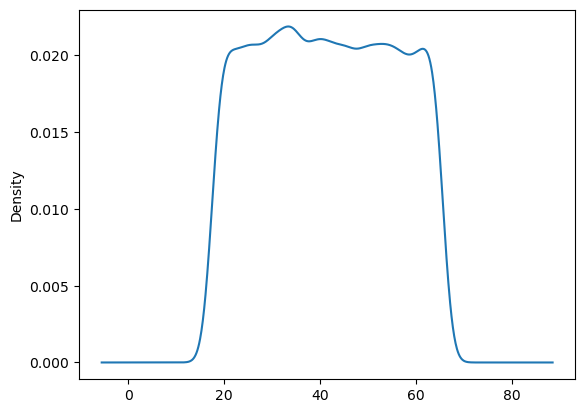

In [4]:
df['age'].plot(kind = 'kde')   # created a KDE plot to visualize the distribution of age values

In [6]:
df['sleep_hours'].astype('datetime64[ns]')  # converted the sleep hours column data type into datetime format

0       1970-01-01 00:00:00.000000005
1       1970-01-01 00:00:00.000000005
2       1970-01-01 00:00:00.000000008
3       1970-01-01 00:00:00.000000006
4       1970-01-01 00:00:00.000000005
                     ...             
29995   1970-01-01 00:00:00.000000005
29996   1970-01-01 00:00:00.000000003
29997   1970-01-01 00:00:00.000000005
29998   1970-01-01 00:00:00.000000006
29999   1970-01-01 00:00:00.000000006
Name: sleep_hours, Length: 30000, dtype: datetime64[ns]

In [9]:
df['work_hours_per_day'].fillna(df['work_hours_per_day'].mean())  # filled missing values in the work_hours_per_day column with the mean value of the column

0         6.753558
1         9.169296
2         7.910952
3         6.355027
4         6.214096
           ...    
29995    10.226358
29996     4.692862
29997    10.915036
29998     6.937410
29999     8.069883
Name: work_hours_per_day, Length: 30000, dtype: float64

In [10]:
df.select_dtypes(include="int64")   # selected all columns with int64 data type from the dataframe

,age,number_of_notifications,breaks_during_work,coffee_consumption_per_day,days_feeling_burnout_per_month
0,56,61,8,4,11
1,46,59,7,2,25
2,32,57,0,3,17
3,60,59,1,0,4
4,25,66,1,1,30
...,...,...,...,...,...
29995,34,59,9,4,5
29996,39,46,3,1,29
29997,42,64,10,1,2
29998,20,56,1,2,9


In [11]:
df.select_dtypes(include=['object','int64'])  # selected all columns with object and int64 data types from the dataframe

,age,gender,job_type,social_platform_preference,number_of_notifications,breaks_during_work,coffee_consumption_per_day,days_feeling_burnout_per_month
0,56,Male,Unemployed,Facebook,61,8,4,11
1,46,Male,Health,Twitter,59,7,2,25
2,32,Male,Finance,Twitter,57,0,3,17
3,60,Female,Unemployed,Facebook,59,1,0,4
4,25,Male,IT,Telegram,66,1,1,30
...,...,...,...,...,...,...,...,...
29995,34,Female,Health,Facebook,59,9,4,5
29996,39,Male,Health,Instagram,46,3,1,29
29997,42,Male,Education,TikTok,64,10,1,2
29998,20,Female,Education,Instagram,56,1,2,9


In [22]:
sum(df['job_type'] == 'IT')   # counted the number of rows where the job type is 'IT'

5026

In [23]:
sum((df['gender'] == 'Male') & (df['job_type'] == 'Finance'))    # counted the number of Male employees whose job type is 'Finance'

2415

In [26]:
sum((df['gender'] == 'Female') & (df['job_type'] == 'Health') & (df['coffee_consumption_per_day'] == 2))   
# counted the number of Female employees whose job type is 'Health' and coffee consumption per day is 2

652

In [29]:
df[df['gender'] == 'Male'][['gender','social_platform_preference']df['Gender'].value_counts().plot(kind = 'bar')]
# filtered rows where gender is Male and selected gender and social platform preference columns

,gender,social_platform_preference
0,Male,Facebook
1,Male,Twitter
2,Male,Twitter
4,Male,Telegram
5,Male,Twitter
...,...,...
29991,Male,Twitter
29994,Male,Twitter
29996,Male,Instagram
29997,Male,TikTok


<Axes: xlabel='gender'>

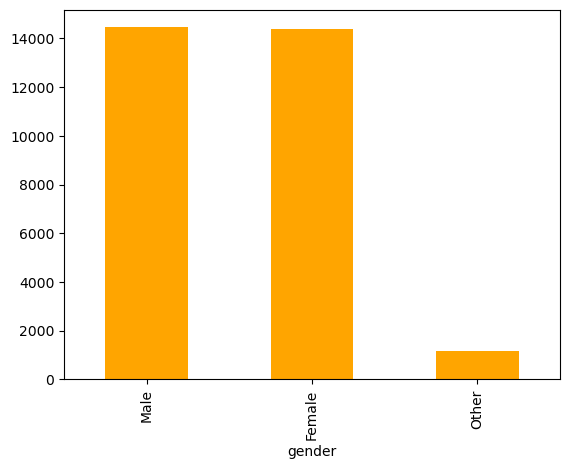

In [31]:
df['gender'].value_counts().plot(kind = 'bar', color = 'orange')  # created a bar chart to visualize the count of each gender using orange color

In [3]:
df

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
2,32,Male,Finance,NaN,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,NaN,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
4,25,Male,IT,NaN,Telegram,66,6.214096,8.868753,NaN,7.0,5.405706,1.876254,1,False,True,1,30,10.653519,9.693060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,34,Female,Health,1.877297,Facebook,59,10.226358,3.348512,3.465815,8.0,5.480462,1.412655,9,False,False,4,5,21.776927,NaN
29996,39,Male,Health,4.437784,Instagram,46,4.692862,8.133213,6.659294,8.0,3.045393,0.148936,3,False,False,1,29,4.111370,6.155613
29997,42,Male,Education,17.724981,TikTok,64,10.915036,8.611005,8.658912,5.0,5.491520,1.224296,10,False,False,1,2,1.888315,6.285237
29998,20,Female,Education,3.796634,Instagram,56,6.937410,7.767076,6.895583,8.0,6.816069,0.234483,1,False,False,2,9,12.511871,7.854711


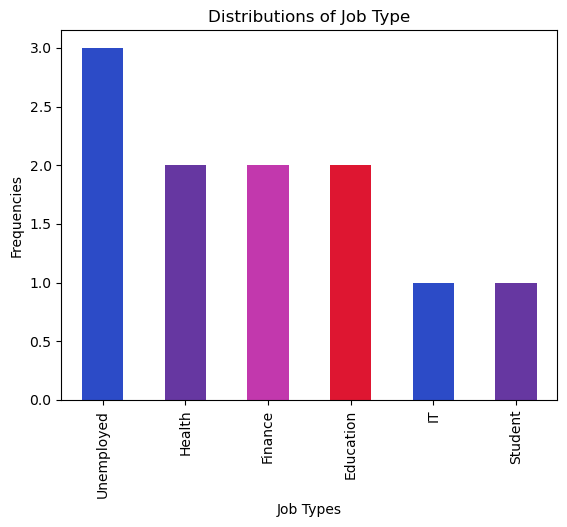

In [65]:
df['job_type'].value_counts().plot(kind = 'bar', color = ['#2c4bc7','#6637a1','#c238ad','#de1631'])
plt.xlabel("Job Types")
plt.ylabel("Frequencies")
plt.title("Distributions of Job Type")
plt.show()  # created a bar chart to visualize the distribution of job types with custom colors

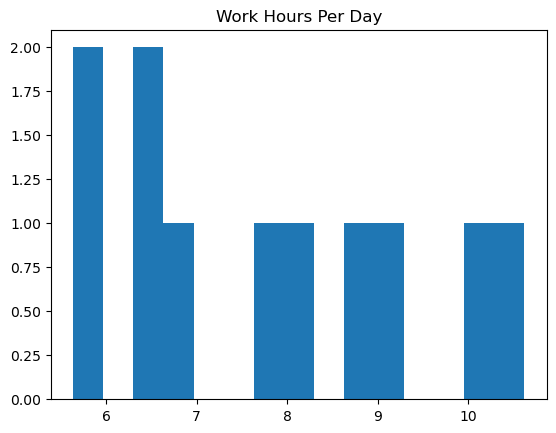

In [66]:
plt.hist(df['work_hours_per_day'], bins= 15 )
plt.title('Work Hours Per Day')
plt.show()   # created a histogram to visualize the distribution of work hours per day

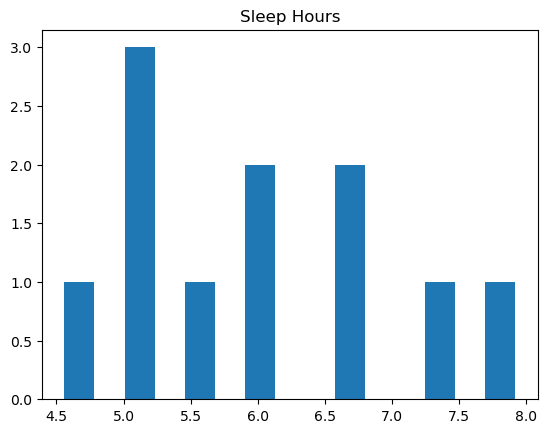

In [69]:
plt.hist(df['sleep_hours'], bins= 15 )
plt.title('Sleep Hours')
plt.show()  # Created a histogram to visualize the distribution of sleep hours

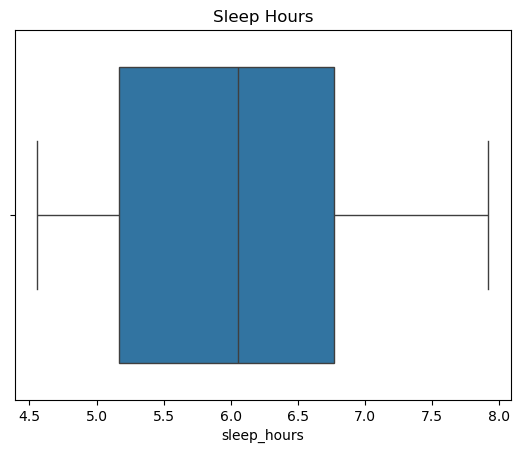

In [72]:
sns.boxplot(x=df['sleep_hours'])
plt.title("Sleep Hours")
plt.show()   # Created a boxplot to visualize the distribution of sleep hours

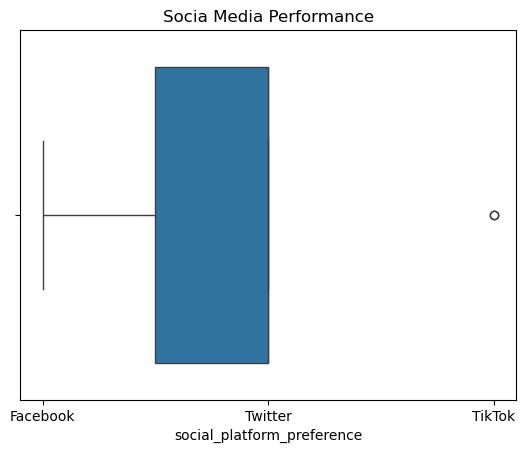

In [74]:
sns.boxplot(x=df['social_platform_preference'])
plt.title("Socia Media Performance")
plt.show()   # Created a boxplot to visualize the distribution of social platform preference

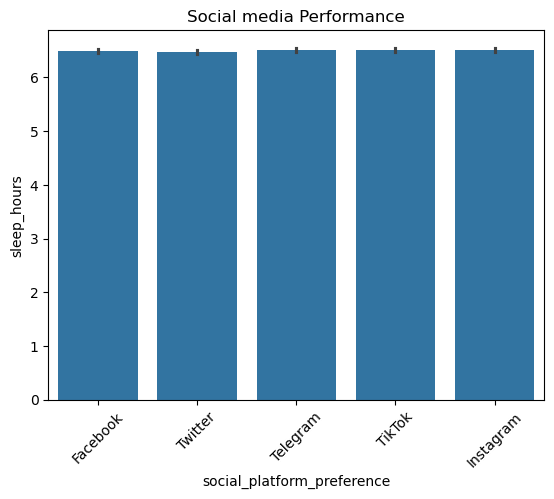

In [9]:
sns.barplot(x='social_platform_preference', y='sleep_hours', data=df)
plt.xticks(rotation=45)
plt.title('Social media Performance')
plt.show()  # Created a barplot to visualize the relationship between social platform preference and sleep hours

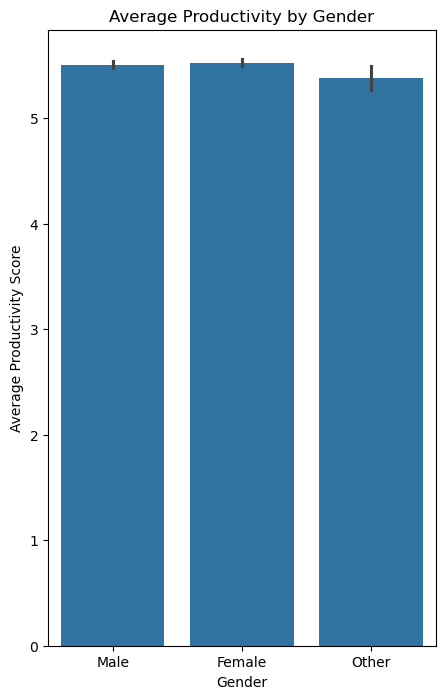

In [6]:
plt.figure(figsize=(5,8))
sns.barplot(x='gender', y='perceived_productivity_score', data=df)
plt.title('Average Productivity by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Productivity Score')
plt.show()       # Created a barplot to compare average productivity scores between genders

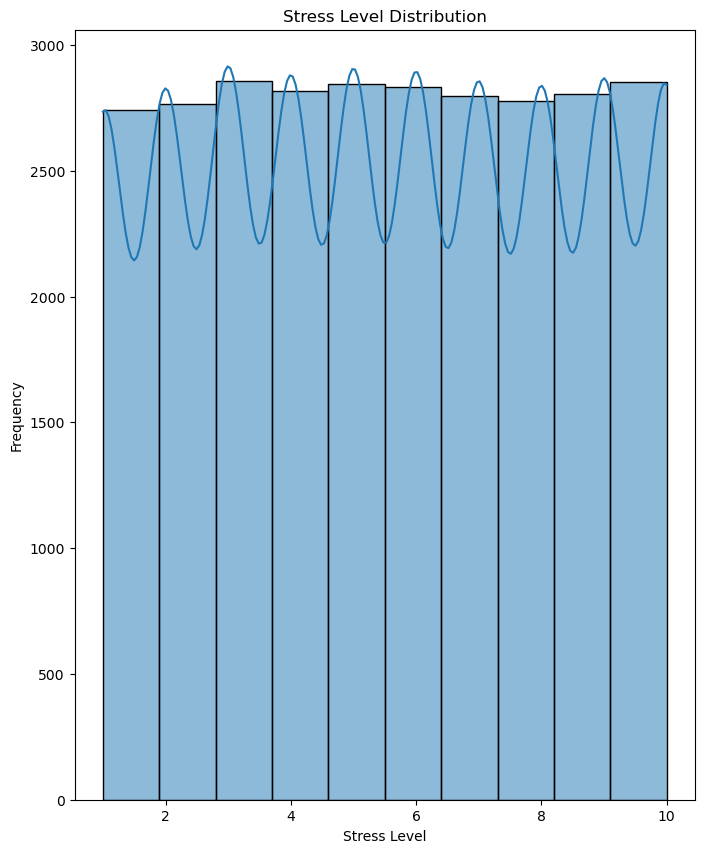

In [9]:
plt.figure(figsize=(8,10))
sns.histplot(df['stress_level'], bins=10, kde= True)
plt.title('Stress Level Distribution')
plt.xlabel('Stress Level')
plt.ylabel('Frequency')
plt.show()      # Created a histogram to analyze the distribution of stress levels among employees

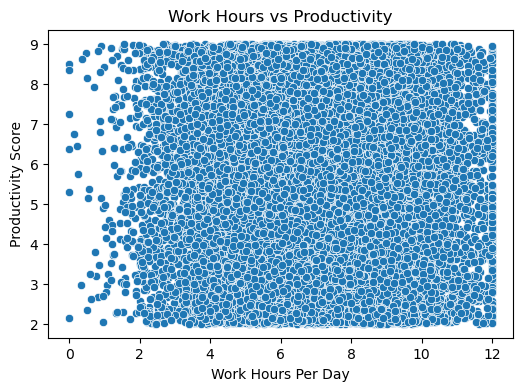

In [10]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='work_hours_per_day', y='perceived_productivity_score', data=df)
plt.title('Work Hours vs Productivity')
plt.xlabel('Work Hours Per Day')
plt.ylabel('Productivity Score')
plt.show()      # Created a scatterplot to examine the relationship between work hours and productivity

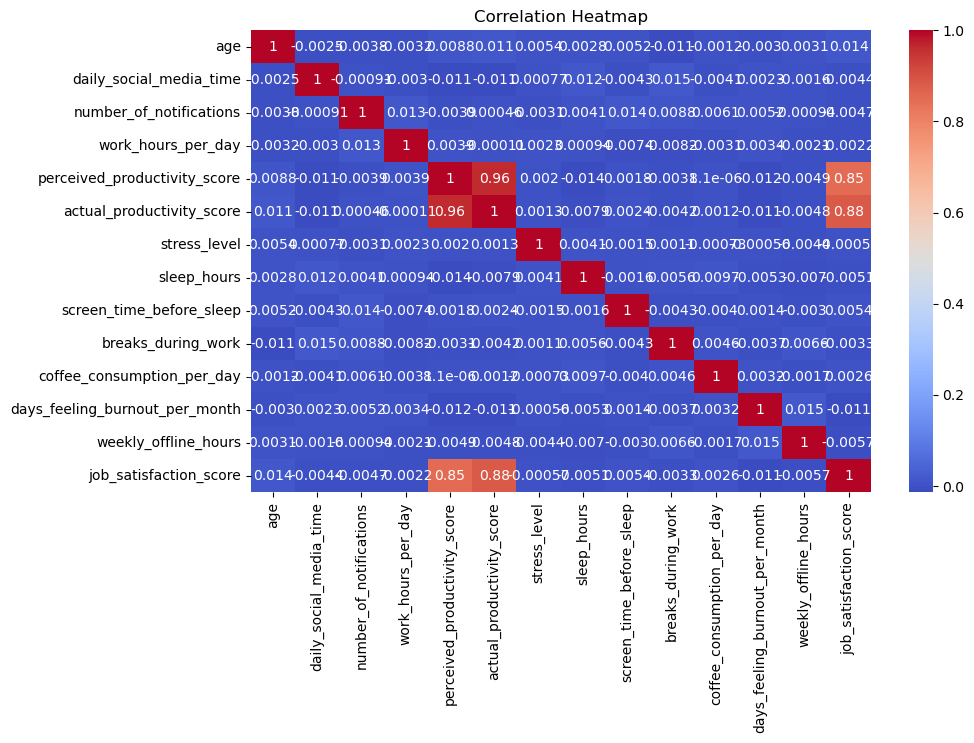

In [11]:
numeric = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()           # Selected only numerical columns for correlation analysis

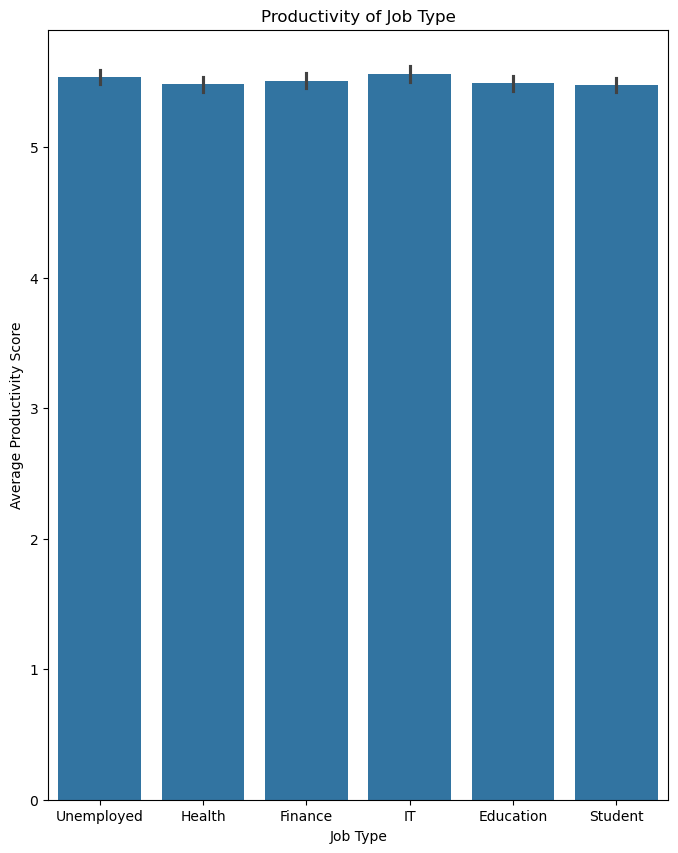

In [13]:
plt.figure(figsize=(8,10))
sns.barplot(x = 'job_type', y = 'perceived_productivity_score', data= df)
plt.title('Productivity of Job Type')
plt.xlabel('Job Type')
plt.ylabel('Average Productivity Score')
plt.show()           # Created a barplot to compare productivity scores across different job types

In [11]:
df.groupby('social_platform_preference')['sleep_hours'].mean()  # Calculated the average sleep hours for each social platform preference category

social_platform_preference
Facebook     6.495470
Instagram    6.507793
Telegram     6.517430
TikTok       6.502661
Twitter      6.477398
Name: sleep_hours, dtype: float64

In [12]:
df.groupby('job_type')['daily_social_media_time'].mean() # Calculated the average daily social media time for each job_type category

job_type
Education     3.104158
Finance       3.078461
Health        3.069378
IT            3.132481
Student       3.139372
Unemployed    3.156376
Name: daily_social_media_time, dtype: float64

<Axes: >

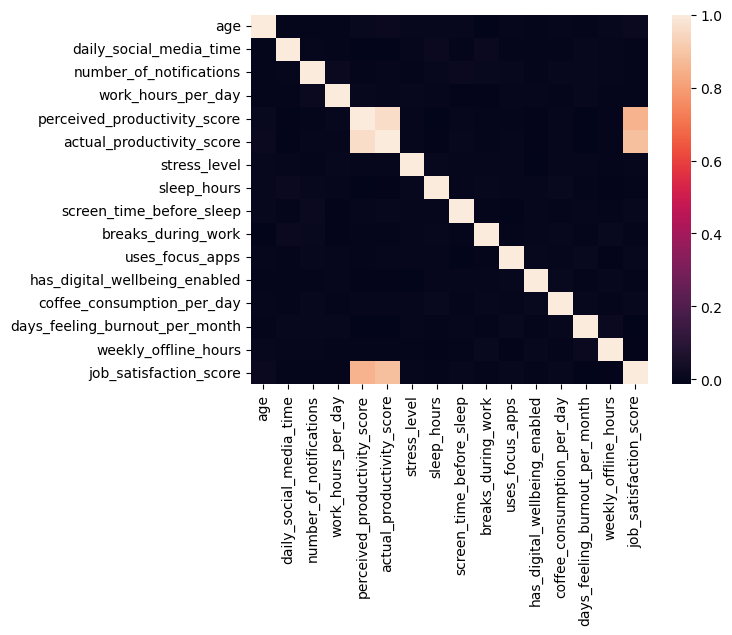

In [27]:
sns.heatmap(df.corr(numeric_only= True ))   # Created a heatmap to visualize correlations between numerical columns

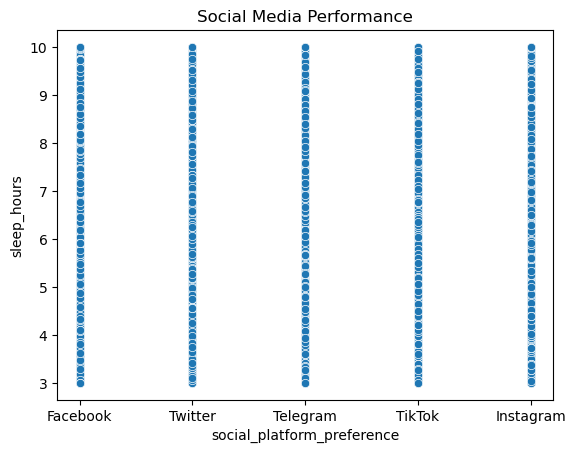

In [3]:
sns.scatterplot(x = 'social_platform_preference', y = 'sleep_hours', data= df )
plt.title('Social Media Performance')
plt.show()  # Created a scatterplot to visualize the relationship between social platform preference and sleep hours

In [4]:
Q1 = df['work_hours_per_day'].quantile(0.25)
Q3 = df['sleep_hours'].quantile(0.75)

IQR = Q3 - Q1  # calculated the IQR

print('The value of Q1:',Q1)
print('The value of Q3:',Q3)
print('The value of IQR:',IQR)

The value of Q1: 5.643771494945799
The value of Q3: 7.5041428957901
The value of IQR: 1.8603714008443006


In [6]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR  # Calculated lower and upper bounds for detecting outliers

outliers = df[(df['daily_social_media_time'] < lower_bound) | 
              (df['daily_social_media_time'] > upper_bound)]        # Filtered outliers from the daily social media time column

print(outliers)

       age  gender    job_type  daily_social_media_time  \
5       38    Male     Finance                 1.512568   
11      41  Female     Finance                 2.200061   
12      53    Male     Student                 2.715760   
13      57    Male   Education                 0.000000   
16      39    Male     Finance                 2.305803   
...    ...     ...         ...                      ...   
29979   51  Female  Unemployed                 0.239934   
29984   21    Male   Education                 0.793902   
29992   44  Female  Unemployed                 1.648825   
29995   34  Female      Health                 1.877297   
29997   42    Male   Education                17.724981   

      social_platform_preference  number_of_notifications  work_hours_per_day  \
5                        Twitter                       50            6.429312   
11                       Twitter                       59           10.147732   
12                        TikTok                

In [10]:
for col in ['daily_social_media_time','work_hours_per_day','sleep_hours']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    print(col,"IQR:",IQR)   # Calculated and displayed the IQR for multiple numerical columns

daily_social_media_time IQR: 2.729350965862388
work_hours_per_day IQR: 2.7109534170800327
sleep_hours IQR: 2.0106073005553364


In [28]:
df.info()  # Displayed information about the dataframe including columns,data types, and non-null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             30000 non-null  int64  
 1   gender                          30000 non-null  object 
 2   job_type                        30000 non-null  object 
 3   social_platform_preference      30000 non-null  object 
 4   number_of_notifications         30000 non-null  int64  
 5   work_hours_per_day              30000 non-null  float64
 6   perceived_productivity_score    30000 non-null  float64
 7   actual_productivity_score       30000 non-null  float64
 8   stress_level                    30000 non-null  float64
 9   sleep_hours                     30000 non-null  float64
 10  screen_time_before_sleep        30000 non-null  float64
 11  breaks_during_work              30000 non-null  int64  
 12  uses_focus_apps                 

## Interpretation

* Most users spend a moderate amount of time on social media daily.
* Platforms such as Instagram, TikTok, and Facebook are among the most preferred social media platforms.
* Sleep hours slightly vary based on social media platform preference.
* Users with higher social media usage tend to show changes in productivity and sleep patterns.
* The correlation heatmap helps identify relationships between numerical features like work hours, sleep hours, and social media time.
* Outlier detection using IQR identified unusual values in social media usage and work hours.
* Visualization techniques such as histograms, boxplots, scatterplots, and bar charts helped understand data distribution and behavioral patterns.
* Overall, the analysis shows that social media usage can influence productivity, daily routine, and lifestyle habits.
